In [166]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


# Data Pre-Processing and Cleaning

In [167]:
import pandas as pd

df = pd.read_csv("bank-additional-full.csv", sep=';')
df['converted'] = df['y'].map({'yes': 1, 'no': 0})



In [168]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,converted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


In [169]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

,0
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0


In [170]:
duplicates = df[df.duplicated(keep=False)]
print(duplicates)

       age          job   marital            education  default housing loan  \
1265    39  blue-collar   married             basic.6y       no      no   no   
1266    39  blue-collar   married             basic.6y       no      no   no   
12260   36      retired   married              unknown       no      no   no   
12261   36      retired   married              unknown       no      no   no   
14155   27   technician    single  professional.course       no      no   no   
14234   27   technician    single  professional.course       no      no   no   
16819   47   technician  divorced          high.school       no     yes   no   
16956   47   technician  divorced          high.school       no     yes   no   
18464   32   technician    single  professional.course       no     yes   no   
18465   32   technician    single  professional.course       no     yes   no   
20072   55     services   married          high.school  unknown      no   no   
20216   55     services   married       

In [171]:
df = df.drop_duplicates()

In [172]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,converted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,0


# Data Analysis

## Funnel Metrics

In [173]:
conversion_rate = df['converted'].mean()
print(conversion_rate)

0.11266271614532737


In [174]:
df['is_lead'] = df['duration'] > 0

total_visitors = len(df)
total_leads = df['is_lead'].sum()
total_customers = df['converted'].sum()

visitor_to_lead = total_leads / total_visitors
lead_to_customer = total_customers / total_leads

In [175]:
funnel = pd.DataFrame({
    'Stage': ['Visitors', 'Leads', 'Customers'],
    'Count': [total_visitors, total_leads, total_customers]
})

funnel['Conversion Rate'] = funnel['Count'] / funnel['Count'].shift(1)

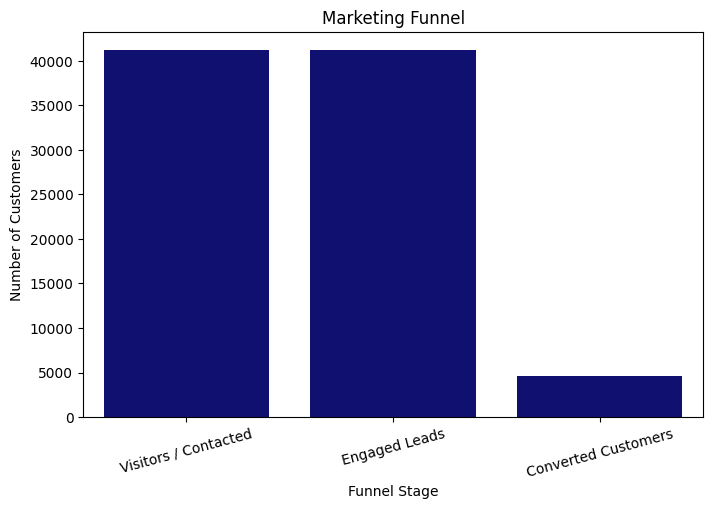

In [176]:
visitors = len(df)
leads = len(df[df["duration"] > 0])
customers = df["converted"].sum()

funnel_df = pd.DataFrame({
    "Stage": ["Visitors / Contacted", "Engaged Leads", "Converted Customers"],
    "Count": [visitors, leads, customers]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_df, x="Stage", y="Count", color= '#000080')
plt.title("Marketing Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()

## Drop-Off Points

In [177]:
drop_off_visitor_to_lead = 1 - visitor_to_lead
drop_off_lead_to_customer = 1 - lead_to_customer

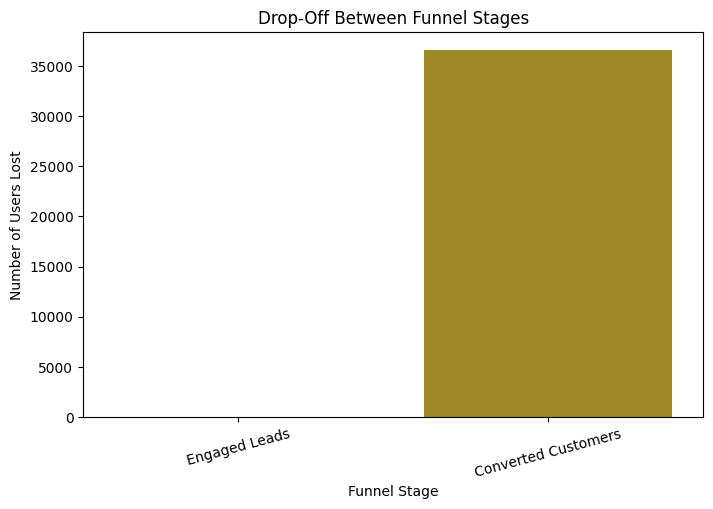

In [178]:
funnel_df["Drop-off"] = funnel_df["Count"].shift(1) - funnel_df["Count"]

plt.figure(figsize=(8, 5))
sns.barplot(data=funnel_df.iloc[1:], x="Stage", y="Drop-off", color= '#B29414')
plt.title("Drop-Off Between Funnel Stages")
plt.xlabel("Funnel Stage")
plt.ylabel("Number of Users Lost")
plt.xticks(rotation=15)
plt.show()

## Campaign Analysis

In [179]:
df.groupby('contact')['converted'].mean()

,converted
contact,
cellular,0.147389
telephone,0.052324


In [180]:
df.groupby('month')['converted'].mean().sort_values(ascending=False)

,converted
month,
mar,0.505495
dec,0.489011
sep,0.449123
oct,0.439331
apr,0.204865
aug,0.106056
jun,0.105115
nov,0.101463
jul,0.090389


In [181]:
df.groupby('campaign')['converted'].mean()

,converted
campaign,
1,0.130373
2,0.114591
3,0.107491
4,0.093962
5,0.075047
6,0.076609
7,0.060413
8,0.042500
9,0.060071


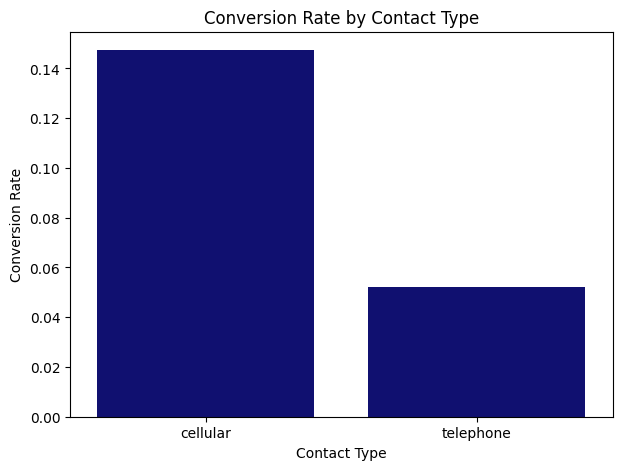

In [182]:
contact_conv = df.groupby("contact")["converted"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=contact_conv, x="contact", y="converted", color= '#000080')
plt.title("Conversion Rate by Contact Type")
plt.xlabel("Contact Type")
plt.ylabel("Conversion Rate")
plt.show()

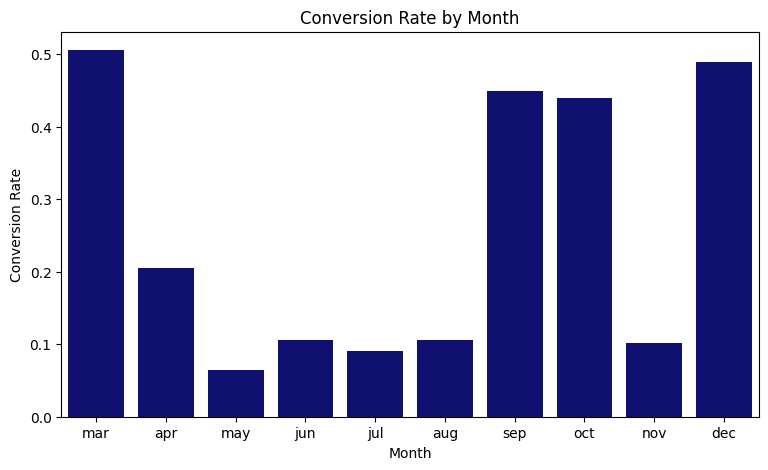

In [183]:
month_order = ["mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"]

month_conv = df.groupby("month")["converted"].mean().reindex(month_order).reset_index()

plt.figure(figsize=(9, 5))
sns.barplot(data=month_conv, x="month", y="converted", color= '#000080')
plt.title("Conversion Rate by Month")
plt.xlabel("Month")
plt.ylabel("Conversion Rate")
plt.show()

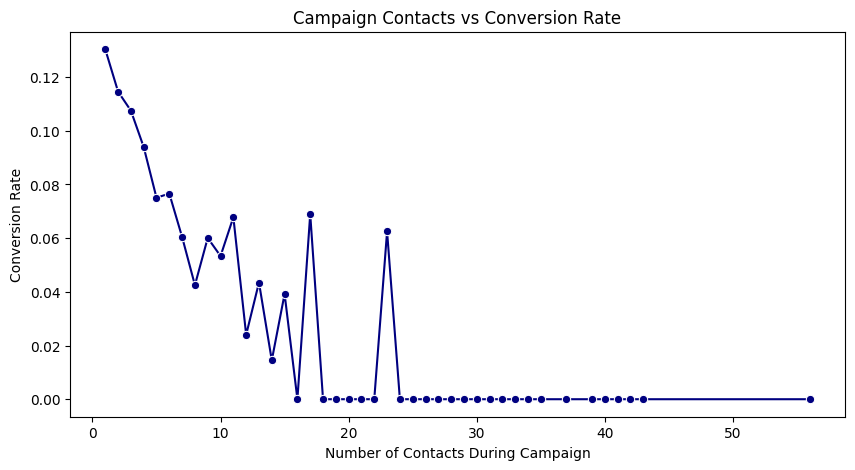

In [184]:
campaign_conv = df.groupby("campaign")["converted"].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(data=campaign_conv, x="campaign", y="converted", marker="o", color= '#000080')
plt.title("Campaign Contacts vs Conversion Rate")
plt.xlabel("Number of Contacts During Campaign")
plt.ylabel("Conversion Rate")
plt.show()

In [185]:
df.groupby('poutcome')['converted'].mean()

,converted
poutcome,
failure,0.142286
nonexistent,0.088324
success,0.651129


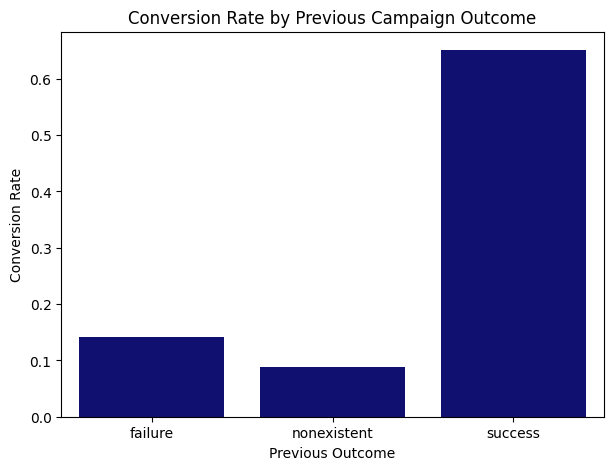

In [186]:
poutcome_conv = df.groupby("poutcome")["converted"].mean().reset_index()

plt.figure(figsize=(7, 5))
sns.barplot(data=poutcome_conv, x="poutcome", y="converted", color= '#000080')
plt.title("Conversion Rate by Previous Campaign Outcome")
plt.xlabel("Previous Outcome")
plt.ylabel("Conversion Rate")
plt.show()

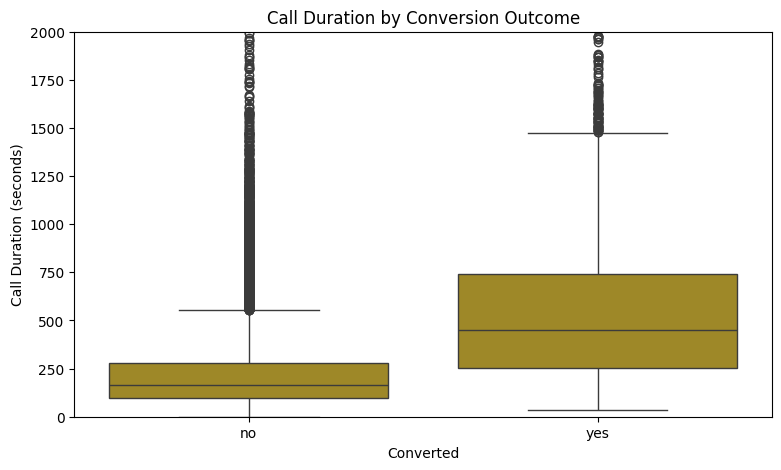

In [187]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x="y", y="duration", color= '#B29414')
plt.title("Call Duration by Conversion Outcome")
plt.xlabel("Converted")
plt.ylabel("Call Duration (seconds)")
plt.ylim(0, 2000)
plt.show()

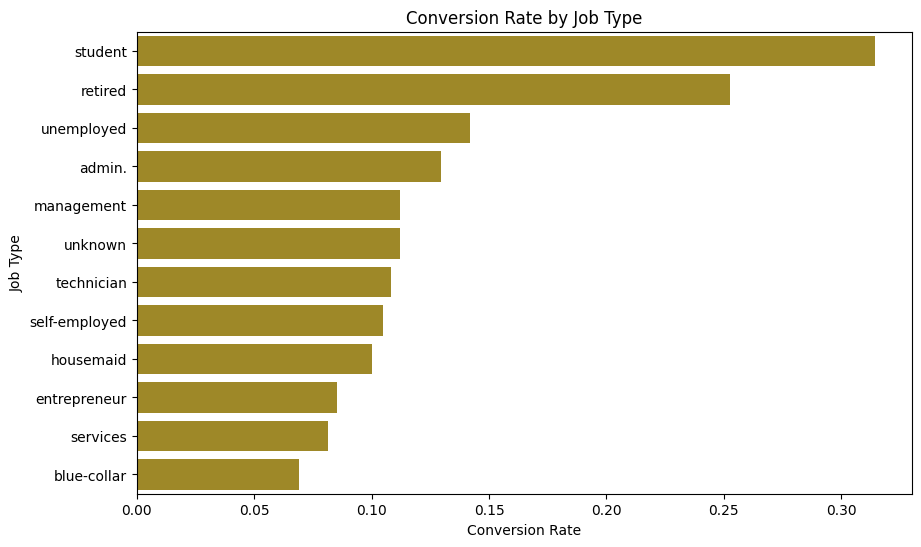

In [188]:
job_conv = df.groupby("job")["converted"].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=job_conv, x="converted", y="job", color= '#B29414')
plt.title("Conversion Rate by Job Type")
plt.xlabel("Conversion Rate")
plt.ylabel("Job Type")
plt.show()

## Engagement vs Conversion

In [189]:
df.groupby(pd.cut(df['duration'], bins=5))['converted'].mean()

/tmp/ipykernel_4617/1416902025.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(df['duration'], bins=5))['converted'].mean()


,converted
duration,
"(-4.918, 983.6]",0.100607
"(983.6, 1967.2]",0.588547
"(1967.2, 2950.8]",0.711538
"(2950.8, 3934.4]",0.384615
"(3934.4, 4918.0]",0.500000


# Exports

In [190]:
df.to_csv('bank-additional-full-cleaned.csv', index=False)